=== 基于学习通数据的学情分析与成绩预测模型 ===

1. 数据读取与预处理
成绩等级分布:
成绩等级
良      72
中      42
合格     12
不合格     9
优       7
Name: count, dtype: int64

2. 特征选择与数据预处理
使用的特征: ['音视频学习(100%)', '资料自主学习(100%)', '章节学习次数', '讨论(100%)', '签到(100%)']

签到数据统计:
count    142.000000
mean      97.957746
std        8.550122
min       30.000000
25%      100.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: 签到(100%), dtype: float64
签到数据唯一值: [100  90  80  70  30]
原始样本数: 142
过滤后样本数: 142
过滤后类别分布:
成绩等级
0     9
1    12
2    42
3    72
4     7
Name: count, dtype: int64
过采样完成
过采样后训练集类别分布:
成绩等级
0    50
1    50
2    50
3    50
4    50
Name: count, dtype: int64

3. 模型训练

4. 可视化分析


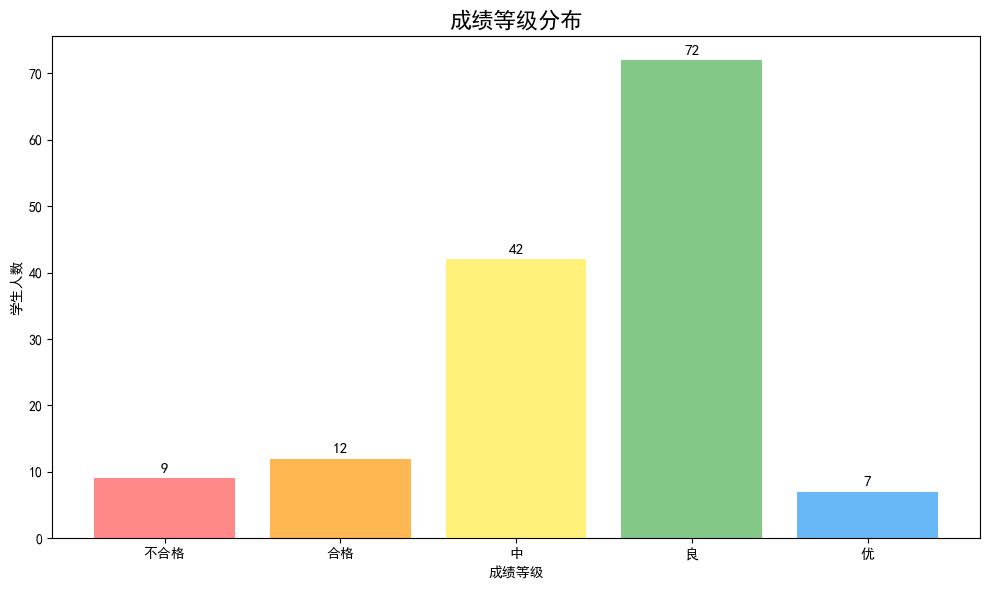

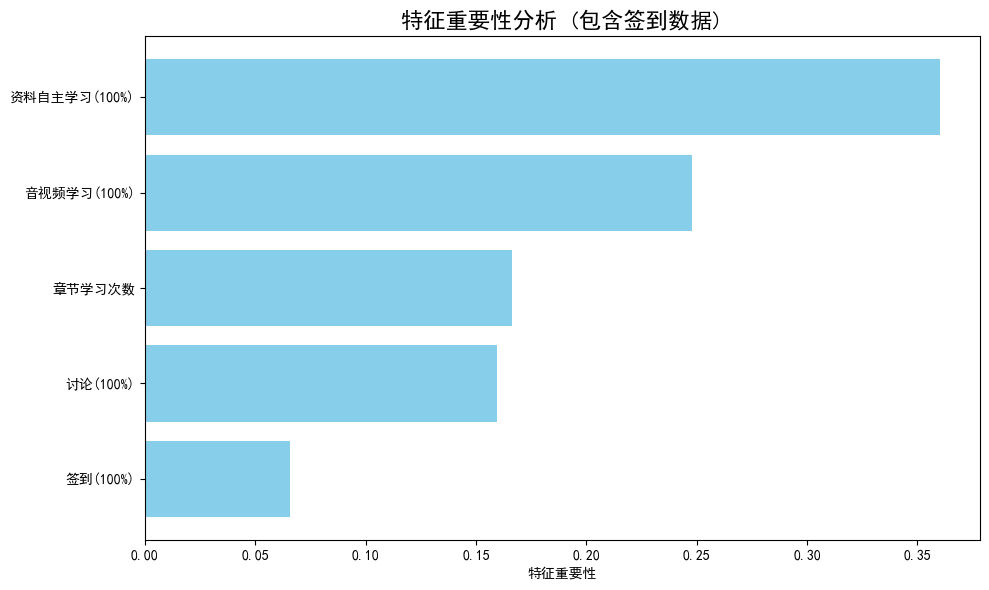

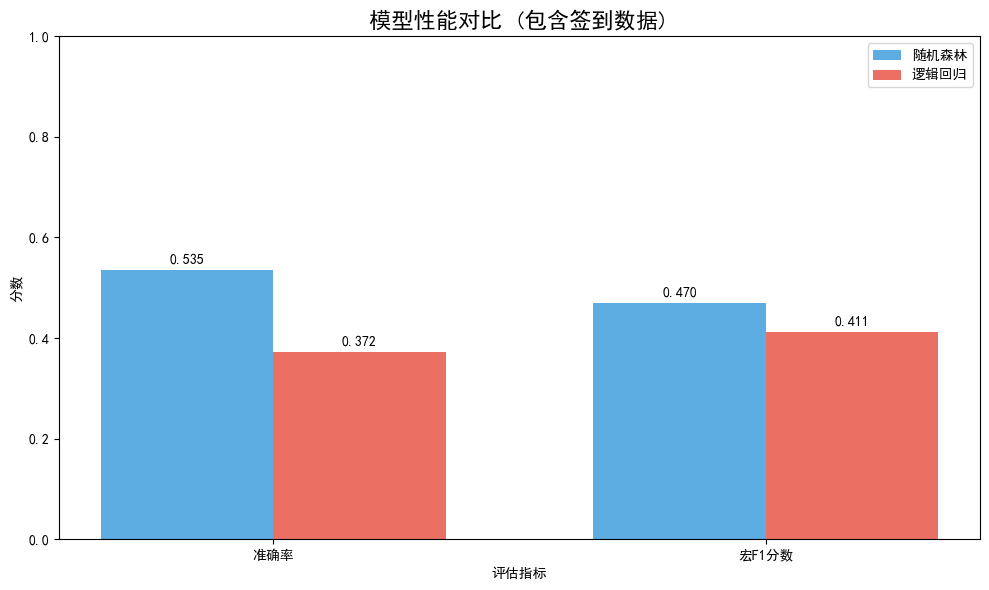

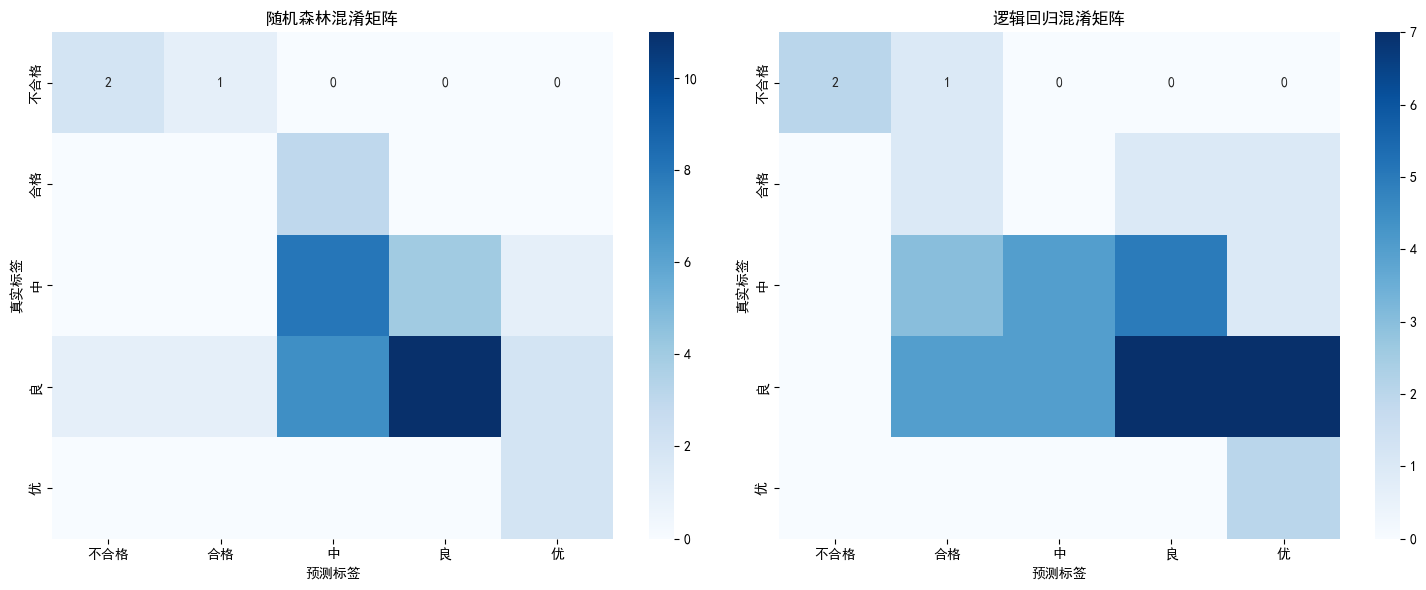


5. 签到数据专项分析


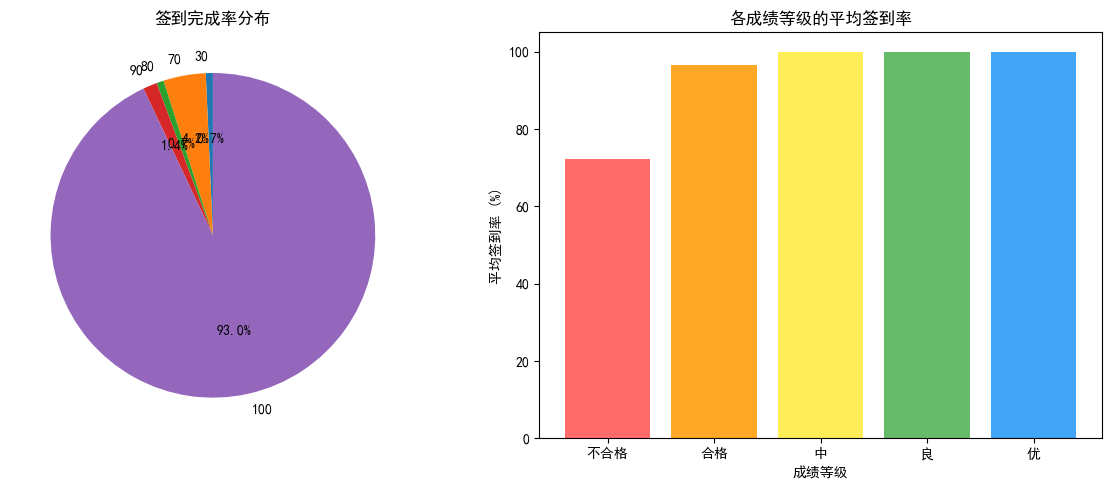


6. 实验结果曲线可视化分析


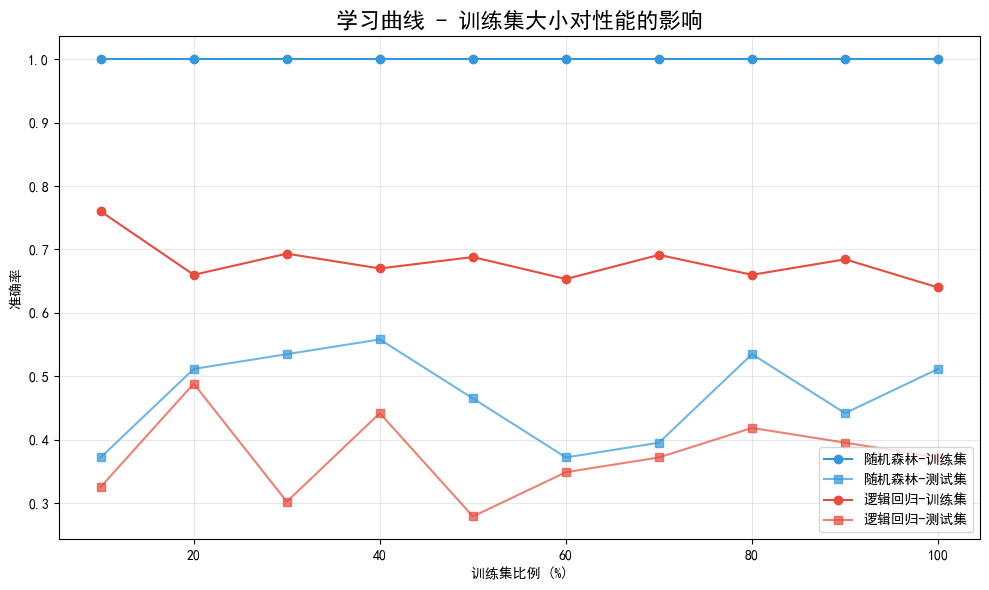

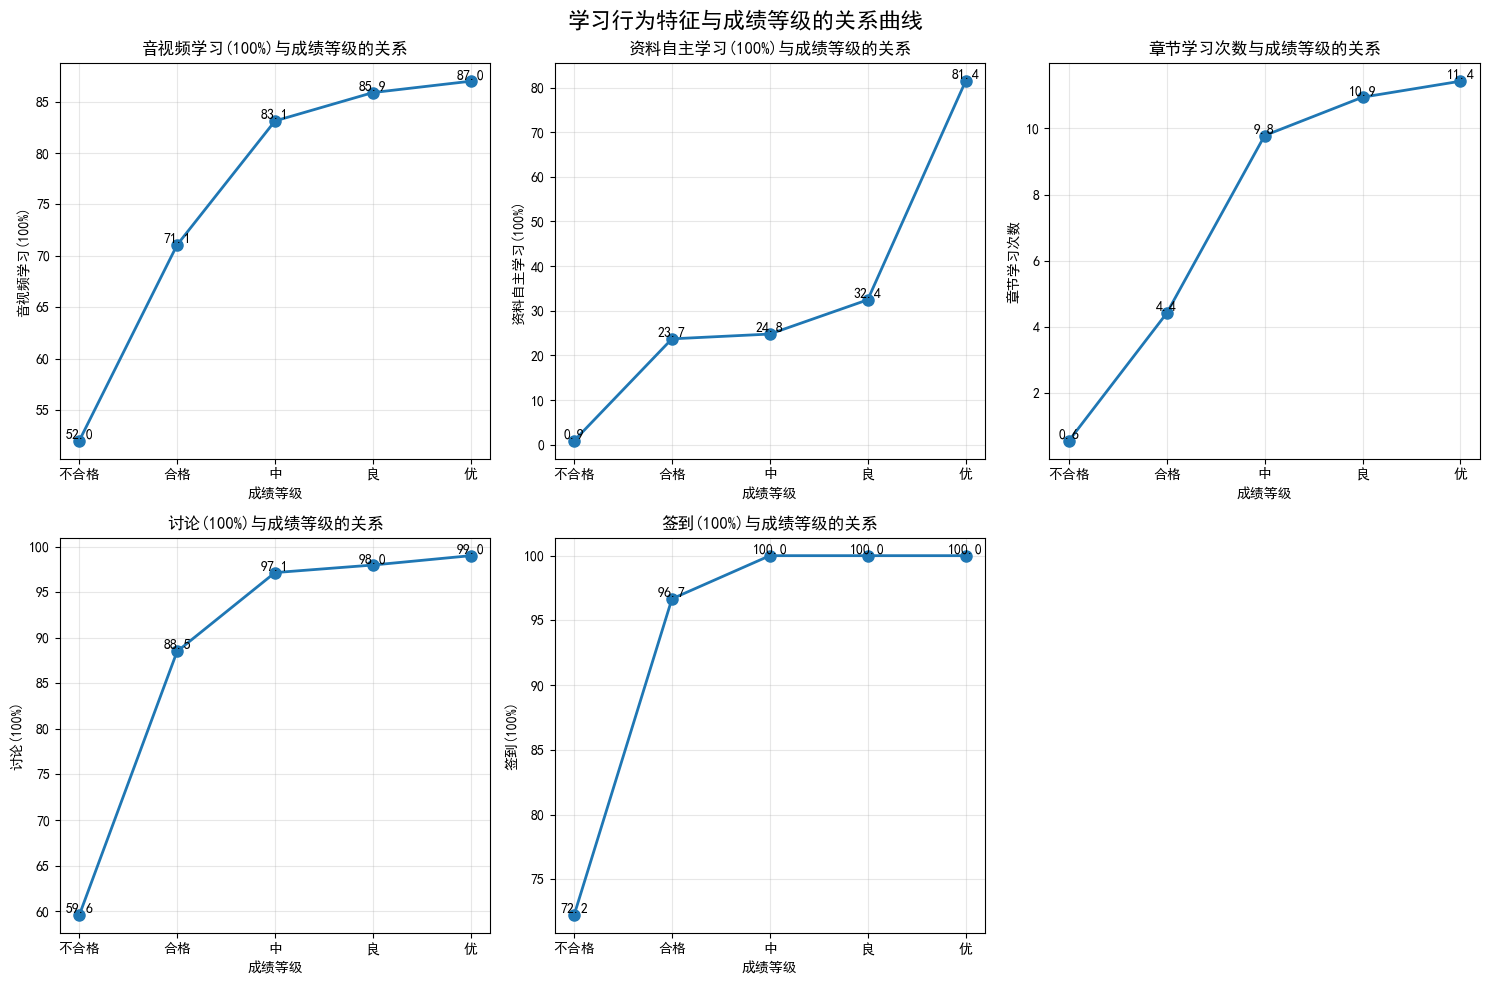


7. 模型性能结果
     模型     准确率   宏F1分数
0  随机森林  0.5349  0.4698
1  逻辑回归  0.3721  0.4111

特征重要性排序:
             特征       重要性
1  资料自主学习(100%)  0.360325
0   音视频学习(100%)  0.247956
2        章节学习次数  0.166488
3      讨论(100%)  0.159666
4      签到(100%)  0.065565

8. 教学启示
基于特征重要性分析的关键发现:
• 资料自主学习(100%) (重要性: 0.360): 反映自主学习能力
• 音视频学习(100%) (重要性: 0.248): 反映认知投入与专注度
• 章节学习次数 (重要性: 0.166): 反映学习持久性与态度
• 讨论(100%) (重要性: 0.160): 反映互动参与度
• 签到(100%) (重要性: 0.066): 反映学习纪律性

主要结论:
1. 最佳模型: 随机森林 (宏F1: 0.470)
2. 最关键特征: 资料自主学习(100%)
3. 学习行为数据能有效预测学业成绩
4. 签到数据作为学习纪律性指标，已纳入模型分析

=== 分析完成 ===
生成的可视化文件:
01_成绩等级分布.png
02_特征重要性分析.png
03_模型性能对比.png
04_混淆矩阵对比.png
05_签到数据分析.png
06_学习曲线.png
07_特征与成绩关系曲线.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report, 
                           confusion_matrix, precision_score, recall_score)
from imblearn.over_sampling import RandomOverSampler
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("=== 基于学习通数据的学情分析与成绩预测模型 ===")

# 1. 数据读取与预处理
print("\n1. 数据读取与预处理")
df = pd.read_excel('学习通学情源数据.xlsx')

# 成绩等级划分
def classify_grade(score):
    if score >= 90: return '优'
    elif score >= 80: return '良'
    elif score >= 70: return '中'
    elif score >= 60: return '合格'
    else: return '不合格'

df['成绩等级'] = df['闭卷考试成绩(100%)'].apply(classify_grade)

# 检查类别分布
grade_dist = df['成绩等级'].value_counts()
print("成绩等级分布:")
print(grade_dist)

# 2. 重新考虑特征选择 - 包含签到数据
print("\n2. 特征选择与数据预处理")

# 重新考虑所有可用特征，包括签到数据
features = ['音视频学习(100%)', '资料自主学习(100%)', '章节学习次数', '讨论(100%)', '签到(100%)']
print("使用的特征:", features)

# 分析签到数据的分布
print("\n签到数据统计:")
print(df['签到(100%)'].describe())
print("签到数据唯一值:", df['签到(100%)'].unique())

X = df[features]
y = df['成绩等级']

# 类别编码
grade_mapping = {'不合格': 0, '合格': 1, '中': 2, '良': 3, '优': 4}
y_encoded = y.map(grade_mapping)

# 移除样本数过少的类别（少于3个样本）
class_counts = y_encoded.value_counts()
valid_classes = class_counts[class_counts >= 3].index.tolist()

mask = y_encoded.isin(valid_classes)
X_filtered = X[mask]
y_filtered = y_encoded[mask]

print(f"原始样本数: {len(X)}")
print(f"过滤后样本数: {len(X_filtered)}")
print("过滤后类别分布:")
print(y_filtered.value_counts().sort_index())

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered
)

# 使用RandomOverSampler替代SMOTE，它更适合小样本情况
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print("过采样完成")
print("过采样后训练集类别分布:")
print(pd.Series(y_train_resampled).value_counts().sort_index())

# 3. 模型训练
print("\n3. 模型训练")

# 随机森林
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# 逻辑回归
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)

# 预测
y_pred_rf = rf_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

# 4. 核心可视化分析
print("\n4. 可视化分析")

# 图表1: 成绩等级分布
plt.figure(figsize=(10, 6))
grade_dist_filtered = y_filtered.value_counts().sort_index()
grade_names = [list(grade_mapping.keys())[i] for i in grade_dist_filtered.index]

plt.bar(grade_names, grade_dist_filtered.values, color=['#ff6b6b', '#ffa726', '#ffee58', '#66bb6a', '#42a5f5'][:len(grade_names)], alpha=0.8)
plt.title('成绩等级分布', fontsize=16, fontweight='bold')
plt.xlabel('成绩等级')
plt.ylabel('学生人数')
for i, v in enumerate(grade_dist_filtered.values):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('01_成绩等级分布.png', dpi=300, bbox_inches='tight')
plt.show()

# 图表2: 特征重要性
plt.figure(figsize=(10, 6))
feature_importance = rf_model.feature_importances_
importance_df = pd.DataFrame({
    '特征': features,
    '重要性': feature_importance
}).sort_values('重要性', ascending=True)

plt.barh(importance_df['特征'], importance_df['重要性'], color='skyblue')
plt.title('特征重要性分析 (包含签到数据)', fontsize=16, fontweight='bold')
plt.xlabel('特征重要性')
plt.tight_layout()
plt.savefig('02_特征重要性分析.png', dpi=300, bbox_inches='tight')
plt.show()

# 图表3: 模型性能对比
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')
f1_macro_lr = f1_score(y_test, y_pred_lr, average='macro')

plt.figure(figsize=(10, 6))
metrics = ['准确率', '宏F1分数']
x = np.arange(len(metrics))
width = 0.35

rf_scores = [accuracy_rf, f1_macro_rf]
lr_scores = [accuracy_lr, f1_macro_lr]

plt.bar(x - width/2, rf_scores, width, label='随机森林', alpha=0.8, color='#3498db')
plt.bar(x + width/2, lr_scores, width, label='逻辑回归', alpha=0.8, color='#e74c3c')

plt.xlabel('评估指标')
plt.ylabel('分数')
plt.title('模型性能对比 (包含签到数据)', fontsize=16, fontweight='bold')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1)

for i, v in enumerate(rf_scores):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
for i, v in enumerate(lr_scores):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('03_模型性能对比.png', dpi=300, bbox_inches='tight')
plt.show()

# 图表4: 混淆矩阵对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 随机森林混淆矩阵
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=grade_names, 
            yticklabels=grade_names, ax=ax1)
ax1.set_title('随机森林混淆矩阵', fontweight='bold')
ax1.set_xlabel('预测标签')
ax1.set_ylabel('真实标签')

# 逻辑回归混淆矩阵
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=grade_names, 
            yticklabels=grade_names, ax=ax2)
ax2.set_title('逻辑回归混淆矩阵', fontweight='bold')
ax2.set_xlabel('预测标签')
ax2.set_ylabel('真实标签')

plt.tight_layout()
plt.savefig('04_混淆矩阵对比.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. 新增特征分析 - 签到数据
print("\n5. 签到数据专项分析")

# 图表5: 签到数据分布
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
signin_counts = df['签到(100%)'].value_counts().sort_index()
plt.pie(signin_counts.values, labels=signin_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('签到完成率分布')

plt.subplot(1, 2, 2)
# 签到与成绩的关系
signin_grade = df.groupby('成绩等级')['签到(100%)'].mean().reindex(grade_names)
plt.bar(range(len(signin_grade)), signin_grade.values, color=['#ff6b6b', '#ffa726', '#ffee58', '#66bb6a', '#42a5f5'][:len(signin_grade)])
plt.title('各成绩等级的平均签到率')
plt.xlabel('成绩等级')
plt.ylabel('平均签到率 (%)')
plt.xticks(range(len(signin_grade)), signin_grade.index)

plt.tight_layout()
plt.savefig('05_签到数据分析.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. 新增实验结果曲线可视化分析
print("\n6. 实验结果曲线可视化分析")

# 图表6: 学习曲线 - 训练集大小对性能的影响
plt.figure(figsize=(10, 6))
train_sizes = np.linspace(0.1, 1.0, 10)
train_scores_rf = []
test_scores_rf = []
train_scores_lr = []
test_scores_lr = []

for size in train_sizes:
    # 按比例采样训练数据
    n_samples = int(size * len(X_train_resampled))
    indices = np.random.choice(len(X_train_resampled), n_samples, replace=False)
    
    X_subset = X_train_resampled[indices]
    y_subset = y_train_resampled[indices]
    
    # 随机森林
    rf_model_temp = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model_temp.fit(X_subset, y_subset)
    train_scores_rf.append(accuracy_score(y_subset, rf_model_temp.predict(X_subset)))
    test_scores_rf.append(accuracy_score(y_test, rf_model_temp.predict(X_test)))
    
    # 逻辑回归
    lr_model_temp = LogisticRegression(random_state=42, max_iter=1000)
    lr_model_temp.fit(X_subset, y_subset)
    train_scores_lr.append(accuracy_score(y_subset, lr_model_temp.predict(X_subset)))
    test_scores_lr.append(accuracy_score(y_test, lr_model_temp.predict(X_test)))

plt.plot(train_sizes*100, train_scores_rf, 'o-', color='#3498db', label='随机森林-训练集')
plt.plot(train_sizes*100, test_scores_rf, 's-', color='#3498db', alpha=0.7, label='随机森林-测试集')
plt.plot(train_sizes*100, train_scores_lr, 'o-', color='#e74c3c', label='逻辑回归-训练集')
plt.plot(train_sizes*100, test_scores_lr, 's-', color='#e74c3c', alpha=0.7, label='逻辑回归-测试集')

plt.xlabel('训练集比例 (%)')
plt.ylabel('准确率')
plt.title('学习曲线 - 训练集大小对性能的影响', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('06_学习曲线.png', dpi=300, bbox_inches='tight')
plt.show()

# 图表7: 特征与成绩的关系曲线
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    
    # 计算每个成绩等级的特征均值
    feature_means = []
    for grade in sorted(y_filtered.unique()):
        grade_mask = y_filtered == grade
        feature_means.append(X_filtered.loc[grade_mask, feature].mean())
    
    plt.plot(grade_names, feature_means, 'o-', linewidth=2, markersize=8)
    plt.title(f'{feature}与成绩等级的关系', fontweight='bold')
    plt.xlabel('成绩等级')
    plt.ylabel(feature)
    plt.grid(True, alpha=0.3)
    
    # 添加数值标签
    for j, v in enumerate(feature_means):
        plt.text(j, v, f'{v:.1f}', ha='center', va='bottom')

plt.suptitle('学习行为特征与成绩等级的关系曲线', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('07_特征与成绩关系曲线.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. 结果分析
print("\n7. 模型性能结果")
performance_df = pd.DataFrame({
    '模型': ['随机森林', '逻辑回归'],
    '准确率': [accuracy_rf, accuracy_lr],
    '宏F1分数': [f1_macro_rf, f1_macro_lr]
})
print(performance_df.round(4))

print("\n特征重要性排序:")
print(importance_df.sort_values('重要性', ascending=False))

print("\n8. 教学启示")
print("基于特征重要性分析的关键发现:")
for idx, row in importance_df.sort_values('重要性', ascending=False).iterrows():
    feature = row['特征']
    importance = row['重要性']
    
    if feature == '章节学习次数':
        print(f"• {feature} (重要性: {importance:.3f}): 反映学习持久性与态度")
    elif feature == '音视频学习(100%)':
        print(f"• {feature} (重要性: {importance:.3f}): 反映认知投入与专注度")
    elif feature == '资料自主学习(100%)':
        print(f"• {feature} (重要性: {importance:.3f}): 反映自主学习能力")
    elif feature == '讨论(100%)':
        print(f"• {feature} (重要性: {importance:.3f}): 反映互动参与度")
    elif feature == '签到(100%)':
        print(f"• {feature} (重要性: {importance:.3f}): 反映学习纪律性")

print("\n主要结论:")
print(f"1. 最佳模型: 随机森林 (宏F1: {f1_macro_rf:.3f})")
print(f"2. 最关键特征: {importance_df.loc[importance_df['重要性'].idxmax(), '特征']}")
print("3. 学习行为数据能有效预测学业成绩")
print("4. 签到数据作为学习纪律性指标，已纳入模型分析")

print("\n=== 分析完成 ===")
print("生成的可视化文件:")
print("01_成绩等级分布.png")
print("02_特征重要性分析.png") 
print("03_模型性能对比.png")
print("04_混淆矩阵对比.png")
print("05_签到数据分析.png")
print("06_学习曲线.png")
print("07_特征与成绩关系曲线.png")